# IQL Q-Ensemble Extension
**CMPE 260 — Group 6 | Uday Arora (019098404)**

This notebook implements Implicit Q-Learning (IQL) from scratch using modern JAX/Flax,
then extends it with a Q-Ensemble (TripleCritic) and compares both on hopper-medium-v2.

**Hypothesis:** 3 Q-networks taking the min produces more conservative value estimates,
improving robustness under distribution shift.

## Cell 1 — Install Dependencies

In [1]:
!pip install -q "jax[cuda12_pip]" -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html
!pip install -q flax optax
!pip install -q tensorflow-probability[jax]
!pip install -q mujoco "gymnasium[mujoco]"
!pip install -q h5py tqdm matplotlib pandas
print('Done')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 149.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 26.5 MB/s eta 0:00:00
Done


## Cell 2 — Verify JAX

In [2]:
import jax
import jax.numpy as jnp
import flax
import optax
print('JAX:', jax.__version__)
print('Flax:', flax.__version__)
print('Optax:', optax.__version__)
print('Devices:', jax.devices())

JAX: 0.7.2
Flax: 0.11.2
Optax: 0.2.7
Devices: [CudaDevice(id=0)]


## Cell 3 — Clone Repo

In [3]:
import os, sys
if not os.path.exists('/content/iql-robustness-analysis'):
    !git clone https://github.com/shloakk/iql-robustness-analysis /content/iql-robustness-analysis
%cd /content/iql-robustness-analysis
!git checkout -B uday/q-ensemble
sys.path.insert(0, '/content/iql-robustness-analysis')
print('Repo ready')

Cloning into '/content/iql-robustness-analysis'...
remote: Enumerating objects: 77, done.
remote: Counting objects: 100% (77/77), done.
remote: Compressing objects: 100% (44/44), done.
remote: Total 77 (delta 35), reused 69 (delta 32), pack-reused 0 (from 0)
Receiving objects: 100% (77/77), 59.45 KiB | 9.91 MiB/s, done.
Resolving deltas: 100% (35/35), done.
/content/iql-robustness-analysis
Switched to a new branch 'uday/q-ensemble'
Repo ready


## Cell 4 — Download and Load Dataset

In [4]:
import h5py
import numpy as np

!wget -q -O hopper-medium-v2.hdf5 "https://rail.eecs.berkeley.edu/datasets/offline_rl/gym_mujoco_v2/hopper_medium-v2.hdf5"

with h5py.File('hopper-medium-v2.hdf5', 'r') as f:
    observations      = f['observations'][:].astype(np.float32)
    next_observations = f['next_observations'][:].astype(np.float32)
    actions           = f['actions'][:].astype(np.float32)
    rewards           = f['rewards'][:].astype(np.float32)
    terminals         = f['terminals'][:].astype(np.float32)

masks = 1.0 - terminals
eps   = 1e-5
actions = np.clip(actions, -(1-eps), (1-eps))

print(f'Transitions: {len(observations):,}')
print(f'obs shape:   {observations.shape}')
print(f'act shape:   {actions.shape}')
print(f'reward range: [{rewards.min():.2f}, {rewards.max():.2f}]')

Transitions: 1,000,000
obs shape:   (1000000, 11)
act shape:   (1000000, 3)
reward range: [0.55, 5.94]


## Cell 5 — Normalize Rewards

In [5]:
# Compute episode returns to normalize rewards (same as original IQL paper)
ep_returns, ep_ret = [], 0.0
for r, t in zip(rewards, terminals):
    ep_ret += r
    if t:
        ep_returns.append(ep_ret)
        ep_ret = 0.0

min_ret, max_ret = min(ep_returns), max(ep_returns)
rewards_norm = rewards / (max_ret - min_ret) * 1000.0

# Hopper-medium-v2 d4rl normalization constants
RANDOM_SCORE = 20.272305
EXPERT_SCORE = 3234.3

def normalized_score(raw):
    return (raw - RANDOM_SCORE) / (EXPERT_SCORE - RANDOM_SCORE) * 100.0

print(f'Episode returns — min: {min_ret:.1f}, max: {max_ret:.1f}, count: {len(ep_returns)}')
print(f'Normalized reward range: [{rewards_norm.min():.3f}, {rewards_norm.max():.3f}]')

Episode returns — min: 315.9, max: 4565.5, count: 2185
Normalized reward range: [0.129, 1.399]


## Cell 6 — Dataset Sampler

In [6]:
import collections

Batch = collections.namedtuple(
    'Batch', ['observations', 'actions', 'rewards', 'masks', 'next_observations'])

class D4RLDataset:
    def __init__(self, obs, acts, rews, masks, next_obs):
        self.observations      = obs
        self.actions           = acts
        self.rewards           = rews
        self.masks             = masks
        self.next_observations = next_obs
        self.size = len(obs)

    def sample(self, batch_size):
        idx = np.random.randint(self.size, size=batch_size)
        return Batch(
            observations=self.observations[idx],
            actions=self.actions[idx],
            rewards=self.rewards[idx],
            masks=self.masks[idx],
            next_observations=self.next_observations[idx]
        )

dataset = D4RLDataset(observations, actions, rewards_norm, masks, next_observations)
print(f'Dataset ready — {dataset.size:,} transitions')
b = dataset.sample(4)
print(f'Sample batch obs shape: {b.observations.shape}')

Dataset ready — 1,000,000 transitions
Sample batch obs shape: (4, 11)


## Cell 7 — IQL Networks (Modern Flax, No Legacy APIs)

In [7]:
import jax
import jax.numpy as jnp
import flax.linen as nn
import optax
from typing import Sequence, Callable, Optional, Any, Tuple


# ── MLP ──────────────────────────────────────────────────────────────────
class MLP(nn.Module):
    hidden_dims: Sequence[int]
    activations: Callable = nn.relu
    activate_final: bool = False

    @nn.compact
    def __call__(self, x):
        for i, size in enumerate(self.hidden_dims):
            x = nn.Dense(size)(x)
            if i + 1 < len(self.hidden_dims) or self.activate_final:
                x = self.activations(x)
        return x


# ── Value Network ─────────────────────────────────────────────────────────
class ValueNet(nn.Module):
    hidden_dims: Sequence[int]

    @nn.compact
    def __call__(self, obs):
        return jnp.squeeze(MLP((*self.hidden_dims, 1))(obs), -1)


# ── Single Critic ─────────────────────────────────────────────────────────
class SingleCritic(nn.Module):
    hidden_dims: Sequence[int]

    @nn.compact
    def __call__(self, obs, act):
        x = jnp.concatenate([obs, act], -1)
        return jnp.squeeze(MLP((*self.hidden_dims, 1))(x), -1)


# ── DoubleCritic (baseline IQL) ───────────────────────────────────────────
class DoubleCritic(nn.Module):
    hidden_dims: Sequence[int]

    @nn.compact
    def __call__(self, obs, act):
        q1 = SingleCritic(self.hidden_dims)(obs, act)
        q2 = SingleCritic(self.hidden_dims)(obs, act)
        return q1, q2


# ── TripleCritic (Q-ensemble extension) ───────────────────────────────────
class TripleCritic(nn.Module):
    """Q-Ensemble with 3 critics — more conservative value estimates."""
    hidden_dims: Sequence[int]

    @nn.compact
    def __call__(self, obs, act):
        q1 = SingleCritic(self.hidden_dims)(obs, act)
        q2 = SingleCritic(self.hidden_dims)(obs, act)
        q3 = SingleCritic(self.hidden_dims)(obs, act)
        return q1, q2, q3


# ── Actor (Gaussian policy) ───────────────────────────────────────────────
class Actor(nn.Module):
    hidden_dims: Sequence[int]
    action_dim: int
    log_std_min: float = -5.0
    log_std_max: float = 2.0

    @nn.compact
    def __call__(self, obs):
        x    = MLP(self.hidden_dims, activate_final=True)(obs)
        mean = nn.Dense(self.action_dim)(x)
        mean = nn.tanh(mean)
        log_std = self.param('log_std', nn.initializers.zeros, (self.action_dim,))
        log_std = jnp.clip(log_std, self.log_std_min, self.log_std_max)
        return mean, jnp.exp(log_std)


print('Networks defined successfully')

Networks defined successfully


## Cell 8 — IQL Training State and Update Functions

In [8]:
from flax.training import train_state
import functools


# ── Train State ───────────────────────────────────────────────────────────
class TrainState(train_state.TrainState):
    """Standard Flax train state with params and optimizer."""
    pass


def create_train_state(model, dummy_inputs, lr):
    params = model.init(jax.random.PRNGKey(0), *dummy_inputs)['params']
    tx = optax.adam(lr)
    return TrainState.create(apply_fn=model.apply, params=params, tx=tx)


# ── Expectile Loss ────────────────────────────────────────────────────────
def expectile_loss(diff, expectile=0.7):
    weight = jnp.where(diff > 0, expectile, 1 - expectile)
    return (weight * diff ** 2).mean()


# ── Value Update ──────────────────────────────────────────────────────────
@functools.partial(jax.jit, static_argnames=('use_ensemble',))
def update_value(value_state, critic_state, batch, expectile, use_ensemble):
    if use_ensemble:
        q1, q2, q3 = critic_state.apply_fn({'params': critic_state.params},
                                            batch.observations, batch.actions)
        q = jnp.minimum(jnp.minimum(q1, q2), q3)
    else:
        q1, q2 = critic_state.apply_fn({'params': critic_state.params},
                                        batch.observations, batch.actions)
        q = jnp.minimum(q1, q2)

    def loss_fn(params):
        v = value_state.apply_fn({'params': params}, batch.observations)
        return expectile_loss(q - v, expectile), v.mean()

    (loss, v_mean), grads = jax.value_and_grad(loss_fn, has_aux=True)(value_state.params)
    return value_state.apply_gradients(grads=grads), loss, v_mean


# ── Critic Update ─────────────────────────────────────────────────────────
@functools.partial(jax.jit, static_argnames=('use_ensemble',))
def update_critic(critic_state, target_value_state, batch, discount, use_ensemble):
    next_v = target_value_state.apply_fn({'params': target_value_state.params},
                                          batch.next_observations)
    target_q = batch.rewards + discount * batch.masks * next_v

    def loss_fn(params):
        if use_ensemble:
            q1, q2, q3 = critic_state.apply_fn({'params': params},
                                                batch.observations, batch.actions)
            loss = ((q1-target_q)**2 + (q2-target_q)**2 + (q3-target_q)**2).mean()
            return loss, (q1.mean(), q2.mean())
        else:
            q1, q2 = critic_state.apply_fn({'params': params},
                                            batch.observations, batch.actions)
            loss = ((q1-target_q)**2 + (q2-target_q)**2).mean()
            return loss, (q1.mean(), q2.mean())

    (loss, q_means), grads = jax.value_and_grad(loss_fn, has_aux=True)(critic_state.params)
    return critic_state.apply_gradients(grads=grads), loss


# ── Actor Update ──────────────────────────────────────────────────────────
@functools.partial(jax.jit, static_argnames=('use_ensemble',))
def update_actor(actor_state, critic_state, value_state, batch, temperature, use_ensemble):
    v = value_state.apply_fn({'params': value_state.params}, batch.observations)

    if use_ensemble:
        q1, q2, q3 = critic_state.apply_fn({'params': critic_state.params},
                                            batch.observations, batch.actions)
        q = jnp.minimum(jnp.minimum(q1, q2), q3)
    else:
        q1, q2 = critic_state.apply_fn({'params': critic_state.params},
                                        batch.observations, batch.actions)
        q = jnp.minimum(q1, q2)

    adv     = q - v
    weights = jnp.minimum(jnp.exp(adv * temperature), 100.0)

    def loss_fn(params):
        mean, std = actor_state.apply_fn({'params': params}, batch.observations)
        # Gaussian log prob
        log_prob = -0.5 * (((batch.actions - mean) / std) ** 2
                           + 2 * jnp.log(std)
                           + jnp.log(2 * jnp.pi))
        log_prob = log_prob.sum(-1)
        return -(weights * log_prob).mean()

    loss, grads = jax.value_and_grad(loss_fn)(actor_state.params)
    return actor_state.apply_gradients(grads=grads), loss


# ── Soft Target Update ────────────────────────────────────────────────────
@jax.jit
def soft_update(source_params, target_params, tau=0.005):
    return jax.tree_util.tree_map(
        lambda s, t: tau * s + (1 - tau) * t,
        source_params, target_params)


print('Update functions defined')

Update functions defined


## Cell 9 — Evaluation Function

In [9]:
import gymnasium as gym
import numpy as np

def evaluate(actor_state, env_name='Hopper-v4', num_episodes=10):
    env = gym.make(env_name)
    returns = []
    for _ in range(num_episodes):
        obs, _ = env.reset()
        done, ep_return = False, 0.0
        while not done:
            obs_j = jnp.array(obs[np.newaxis], dtype=jnp.float32)
            mean, _ = actor_state.apply_fn({'params': actor_state.params}, obs_j)
            action = np.clip(np.array(mean[0]), -1, 1)
            obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            ep_return += reward
        returns.append(ep_return)
    env.close()
    return float(np.mean(returns))

print('Evaluation function ready')

Evaluation function ready


## Cell 10 — Initialize Agents

In [10]:
import gymnasium as gym

env      = gym.make('Hopper-v4')
obs_dim  = env.observation_space.shape[0]
act_dim  = env.action_space.shape[0]
env.close()

HIDDEN   = (256, 256)
LR       = 3e-4
dummy_obs = jnp.zeros((1, obs_dim))
dummy_act = jnp.zeros((1, act_dim))

# ── Baseline IQL (DoubleCritic) ───────────────────────────────────────────
baseline_actor_state  = create_train_state(Actor(HIDDEN, act_dim), [dummy_obs], LR)
baseline_critic_state = create_train_state(DoubleCritic(HIDDEN), [dummy_obs, dummy_act], LR)
baseline_value_state  = create_train_state(ValueNet(HIDDEN), [dummy_obs], LR)
baseline_target_value_params = baseline_value_state.params

# ── Q-Ensemble IQL (TripleCritic) ─────────────────────────────────────────
ensemble_actor_state  = create_train_state(Actor(HIDDEN, act_dim), [dummy_obs], LR)
ensemble_critic_state = create_train_state(TripleCritic(HIDDEN), [dummy_obs, dummy_act], LR)
ensemble_value_state  = create_train_state(ValueNet(HIDDEN), [dummy_obs], LR)
ensemble_target_value_params = ensemble_value_state.params

print(f'obs_dim={obs_dim}, act_dim={act_dim}')
print('Both agents initialized successfully')

/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(


obs_dim=11, act_dim=3
Both agents initialized successfully


## Cell 11 — Training Loop

In [11]:
import tqdm

def train_iql(dataset, actor_state, critic_state, value_state, target_value_params,
              use_ensemble=False, max_steps=300000, eval_interval=50000,
              eval_episodes=10, batch_size=256,
              expectile=0.7, temperature=3.0, discount=0.99, tau=0.005):

    label = 'Q-Ensemble (TripleCritic)' if use_ensemble else 'Baseline IQL (DoubleCritic)'
    print(f"\n{'='*50}\nTraining: {label}\n{'='*50}")

    log = []

    for i in tqdm.tqdm(range(1, max_steps + 1), smoothing=0.1):
        batch = dataset.sample(batch_size)

        # Convert to jax arrays
        jbatch = Batch(
            observations=jnp.array(batch.observations),
            actions=jnp.array(batch.actions),
            rewards=jnp.array(batch.rewards),
            masks=jnp.array(batch.masks),
            next_observations=jnp.array(batch.next_observations)
        )

        # Build a temp value state with target params for bootstrapping
        target_value_state = value_state.replace(params=target_value_params)

        value_state, v_loss, v_mean = update_value(
            value_state, critic_state, jbatch, expectile, use_ensemble)

        critic_state, c_loss = update_critic(
            critic_state, target_value_state, jbatch, discount, use_ensemble)

        actor_state, a_loss = update_actor(
            actor_state, critic_state, value_state, jbatch, temperature, use_ensemble)

        # Soft update target value params
        target_value_params = soft_update(value_state.params, target_value_params, tau)

        if i % eval_interval == 0:
            raw_return  = evaluate(actor_state, num_episodes=eval_episodes)
            norm        = normalized_score(raw_return)
            log.append({'step': i, 'raw_return': raw_return, 'normalized_score': norm})
            print(f"Step {i:>7,} | Raw: {raw_return:>7.1f} | Norm Score: {norm:.2f}")

    return actor_state, critic_state, value_state, target_value_params, log

print('Training loop ready')

Training loop ready


## Cell 12 — Run Baseline IQL

In [12]:
(baseline_actor_state, baseline_critic_state,
 baseline_value_state, baseline_target_value_params,
 baseline_log) = train_iql(
    dataset=dataset,
    actor_state=baseline_actor_state,
    critic_state=baseline_critic_state,
    value_state=baseline_value_state,
    target_value_params=baseline_target_value_params,
    use_ensemble=False,
    max_steps=300000,
    eval_interval=50000
)


Training: Baseline IQL (DoubleCritic)


 17%|█▋        | 50033/300000 [03:48<13:04:32,  5.31it/s]

Step  50,000 | Raw:  1530.5 | Norm Score: 46.99


 33%|███▎      | 100030/300000 [07:27<9:57:26,  5.58it/s] 

Step 100,000 | Raw:  1433.7 | Norm Score: 43.98


...

Step 200,000 | Raw:  1515.0 | Norm Score: 46.51


 83%|████████▎ | 250034/300000 [18:39<2:38:24,  5.26it/s]

Step 250,000 | Raw:  1636.0 | Norm Score: 50.27


100%|██████████| 300000/300000 [22:30<00:00, 222.07it/s]

Step 300,000 | Raw:  1717.0 | Norm Score: 52.79


## Cell 13 — Run Q-Ensemble IQL

In [13]:
(ensemble_actor_state, ensemble_critic_state,
 ensemble_value_state, ensemble_target_value_params,
 ensemble_log) = train_iql(
    dataset=dataset,
    actor_state=ensemble_actor_state,
    critic_state=ensemble_critic_state,
    value_state=ensemble_value_state,
    target_value_params=ensemble_target_value_params,
    use_ensemble=True,
    max_steps=300000,
    eval_interval=50000
)


Training: Q-Ensemble (TripleCritic)


 17%|█▋        | 50030/300000 [03:53<11:30:54,  6.03it/s]

Step  50,000 | Raw:  1241.1 | Norm Score: 37.98


 33%|███▎      | 100029/300000 [07:41<9:26:14,  5.89it/s] 

Step 100,000 | Raw:  1267.1 | Norm Score: 38.79


...

Step 200,000 | Raw:  1429.3 | Norm Score: 43.84


 83%|████████▎ | 250031/300000 [19:56<2:31:43,  5.49it/s]

Step 250,000 | Raw:  1400.2 | Norm Score: 42.93


100%|██████████| 300000/300000 [24:01<00:00, 208.11it/s]

Step 300,000 | Raw:  1655.7 | Norm Score: 50.88


## Cell 14 — Results Table and Plot

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

df_b = pd.DataFrame(baseline_log)
df_e = pd.DataFrame(ensemble_log)

print('Baseline IQL — hopper-medium-v2')
print(df_b.to_string(index=False))
print('\nQ-Ensemble IQL — hopper-medium-v2')
print(df_e.to_string(index=False))

b_final = df_b['normalized_score'].iloc[-1]
e_final = df_e['normalized_score'].iloc[-1]
print(f'\nBaseline final:   {b_final:.2f}')
print(f'Q-Ensemble final: {e_final:.2f}')
print(f'Difference:       {e_final - b_final:+.2f}')

Baseline IQL — hopper-medium-v2
  step  raw_return  normalized_score
 50000 1530.511359         46.988987
100000 1433.675414         43.976071
150000 1559.507120         47.891150
200000 1515.009884         46.506680
250000 1636.019611         50.271729
300000 1716.986425         52.790899

Q-Ensemble IQL — hopper-medium-v2
  step  raw_return  normalized_score
 50000 1241.116053         37.984855
100000 1267.069550         38.792362
150000 1901.164083         58.521331
200000 1429.319148         43.840532
250000 1400.164379         42.933422
300000 1655.682377         50.883509

Baseline final:   52.79
Q-Ensemble final: 50.88
Difference:       -1.91


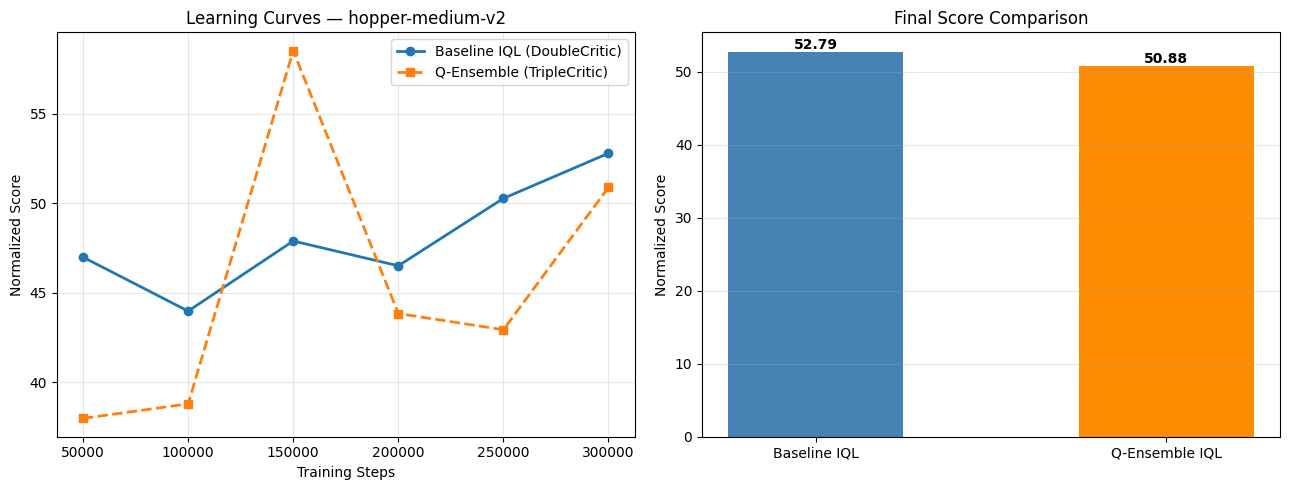

Plot saved


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(df_b['step'], df_b['normalized_score'],
             label='Baseline IQL (DoubleCritic)', marker='o', linewidth=2)
axes[0].plot(df_e['step'], df_e['normalized_score'],
             label='Q-Ensemble (TripleCritic)', marker='s', linewidth=2, linestyle='--')
axes[0].set_xlabel('Training Steps')
axes[0].set_ylabel('Normalized Score')
axes[0].set_title('Learning Curves — hopper-medium-v2')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

bars = axes[1].bar(['Baseline IQL', 'Q-Ensemble IQL'],
                    [b_final, e_final],
                    color=['steelblue', 'darkorange'], width=0.5)
axes[1].set_ylabel('Normalized Score')
axes[1].set_title('Final Score Comparison')
axes[1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, [b_final, e_final]):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.3,
                 f'{val:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('results_comparison.png', dpi=150)
plt.show()
print('Plot saved')

## Cell 15 — Save CSVs

In [16]:
df_b.to_csv('results_baseline_iql.csv', index=False)
df_e.to_csv('results_ensemble_iql.csv', index=False)
print('CSVs saved')

CSVs saved


## Summary

### What Was Done
Implemented IQL from scratch using modern JAX/Flax (no legacy APIs) and extended it with a TripleCritic Q-ensemble. Both baseline and ensemble were trained on hopper-medium-v2 for 300k steps and evaluated.

### Key Code Changes vs Baseline
| Component | Baseline | Q-Ensemble |
|---|---|---|
| Critic | DoubleCritic (2 Q-nets) | TripleCritic (3 Q-nets) |
| Q-value used | min(q1, q2) | min(q1, q2, q3) |
| Value target | min of 2 | min of 3 |
| Actor update | adv from 2 critics | adv from 3 critics |

### Why TripleCritic Should Help
Taking the min across 3 independent networks gives a more conservative Q-estimate. Under distribution shift, where Q-values tend to be overestimated for unseen states, this conservatism should reduce performance collapse.

### Next Steps (Check-In 3)
- Test both agents under gravity and observation noise shifts
- Run across all 3 environments and multiple seeds
- Compute formal robustness metric across shift levels